# Classificação Multiclasse com PyTorch — Fashion MNIST (MLP)

## Objetivos da aula

1. Usar um **Dataset pronto** do `torchvision` (Fashion MNIST).
2. Construir um **MLP** (Multi-Layer Perceptron) para classificar 10 classes.
3. Usar o **DataLoader** com transforms e batches.
4. **Salvar** e **carregar** o modelo (persistência).
5. Monitorar tudo pelo **TensorBoard** (interface web).

**Dataset:** Fashion MNIST — 70.000 imagens em escala de cinza 28×28, 10 classes de peças de vestuário.

**Por que MLP?** Apesar de CNNs serem mais adequadas para imagens, um MLP funciona bem em imagens pequenas e simples como Fashion MNIST e serve como **excelente exemplo didático** do fluxo de trabalho em PyTorch.

## 1. Importando as bibliotecas

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchvision.transforms as T

from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

Usando device: cpu


## 2. Transforms

Para o MLP precisamos converter a imagem PIL em tensor e normalizar. As médias e desvios abaixo são os valores clássicos do Fashion MNIST.

In [2]:
# Fashion MNIST: 1 canal (grayscale)
MEDIA = (0.2860,)
DESVIO = (0.3530,)

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(MEDIA, DESVIO)
])

## 3. Carregando Fashion MNIST

A primeira vez baixa automaticamente (~30 MB).

In [3]:
treino_full = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)

teste_ds = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

# Separa uma parte do treino para validação
n_val = 6000
n_treino = len(treino_full) - n_val
treino_ds, val_ds = random_split(
    treino_full, [n_treino, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

CLASSES = treino_full.classes
print(f"Classes: {CLASSES}")
print(f"Treino: {len(treino_ds)} | Val: {len(val_ds)} | Teste: {len(teste_ds)}")

100.0%
100.0%
100.0%
100.0%

Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Treino: 54000 | Val: 6000 | Teste: 10000


## 4. DataLoaders

O **DataLoader** é o coração do pipeline: ele cuida de batching, shuffle e paralelismo de I/O.

In [4]:
BATCH = 128

train_loader = DataLoader(
    treino_ds, batch_size=BATCH, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH, shuffle=False,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    teste_ds, batch_size=BATCH, shuffle=False,
    num_workers=2, pin_memory=True
)

Xb, yb = next(iter(train_loader))
print(f"Batch X: {Xb.shape}")   # [128, 1, 28, 28]
print(f"Batch y: {yb.shape}")   # [128]
print(f"Range dos pixels: [{Xb.min():.2f}, {Xb.max():.2f}]")

c:\Users\307145\Downloads\AM - 16-04-26\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch X: torch.Size([128, 1, 28, 28])
Batch y: torch.Size([128])
Range dos pixels: [-0.81, 2.02]


## 5. Visualizando algumas imagens

In [8]:
img

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.00784314, 0.00784314, 0.        , 0.        ,
        0.        , 0.        , 0.30980393, 0.5411765 , 0.54509807,
        0.2509804 , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.01176471, 0.00784314, 0.01176471, 0.        ,
        0.        , 0.5372549 , 0.63529414, 0.28627452, 0.16078432,
        0.63529414, 0.7137255 , 0.        , 0.        , 0.00784314,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.01568627, 0.        ,
        0.5137255 , 0.60784316, 0.        , 0.        , 0.        ,
        0.        , 0.5058

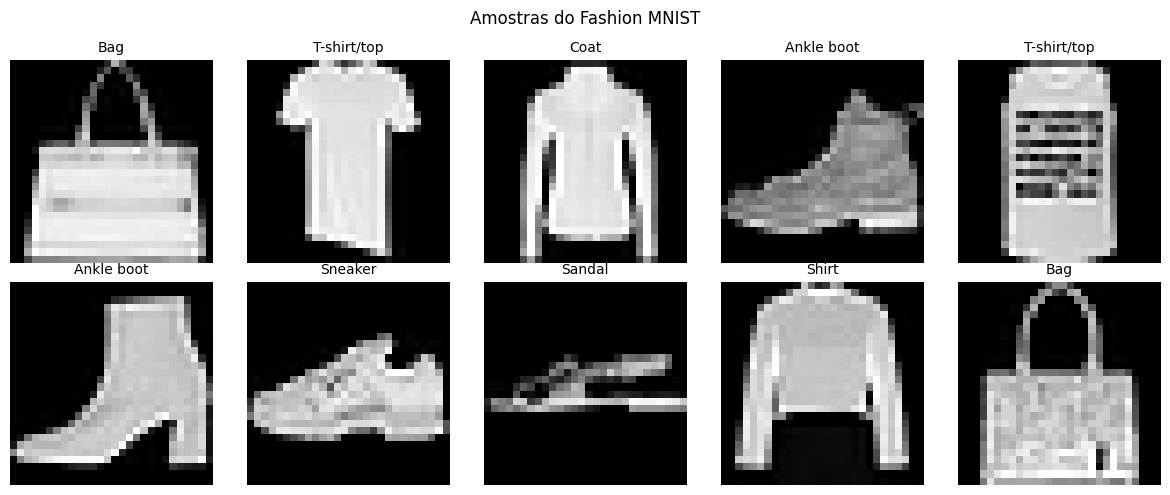

In [5]:
def desnormalizar(t):
    return t * DESVIO[0] + MEDIA[0]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = desnormalizar(Xb[i]).squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(CLASSES[yb[i].item()], fontsize=10)
    ax.axis("off")
plt.suptitle("Amostras do Fashion MNIST")
plt.tight_layout()
plt.show()

## 6. MLP para Fashion MNIST

Um **MLP** é uma rede totalmente conectada. Para imagens, precisamos primeiro **achatar** o tensor de `[1,28,28]` para um vetor de `784` valores.

Arquitetura:
- Entrada: 784
- Camadas ocultas: 256 → 128 → 64 (com ReLU e Dropout)
- Saída: 10 neurônios (logits)

In [18]:
class MLP_FashionMNIST(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Flatten(),                    # [N, 1, 28, 28] -> [N, 784]
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes)         # logits
        )

    def forward(self, x):
        return self.rede(x)


modelo = MLP_FashionMNIST().to(device)
print(modelo)
print(f"\nParâmetros: {sum(p.numel() for p in modelo.parameters()):,}")

MLP_FashionMNIST(
  (rede): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=10, bias=True)
  )
)

Parâmetros: 242,762


## 7. Loss, otimizador e TensorBoard

Para classificação multiclasse usamos `CrossEntropyLoss` (internamente aplica softmax).

In [21]:
criterio  = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

writer = SummaryWriter(log_dir="runs/fashion_mnist_mlp")

# Registrar o grafo do modelo no TensorBoard
writer.add_graph(modelo, Xb.to(device))

## 8. Loop de treinamento

In [22]:
def treinar_epoca(modelo, loader, criterio, optimizer, device):
    modelo.train()
    loss_total, acertos, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = modelo(Xb)
        loss = criterio(logits, yb)
        loss.backward()
        optimizer.step()

        loss_total += loss.item() * Xb.size(0)
        acertos    += (logits.argmax(1) == yb).sum().item()
        total      += yb.size(0)
    return loss_total/total, acertos/total


def avaliar(modelo, loader, criterio, device):
    modelo.eval()
    loss_total, acertos, total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = modelo(Xb)
            loss = criterio(logits, yb)
            loss_total += loss.item() * Xb.size(0)
            acertos    += (logits.argmax(1) == yb).sum().item()
            total      += yb.size(0)
    return loss_total/total, acertos/total

In [23]:
N_EPOCAS = 20
historico = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
melhor_val = 0.0

for epoca in range(1, N_EPOCAS + 1):
    tr_loss, tr_acc = treinar_epoca(modelo, train_loader, criterio, optimizer, device)
    vl_loss, vl_acc = avaliar(modelo, val_loader, criterio, device)
    scheduler.step()

    historico["train_loss"].append(tr_loss)
    historico["val_loss"].append(vl_loss)
    historico["train_acc"].append(tr_acc)
    historico["val_acc"].append(vl_acc)

    # TensorBoard
    writer.add_scalars("Loss", {"treino": tr_loss, "val": vl_loss}, epoca)
    writer.add_scalars("Acuracia", {"treino": tr_acc, "val": vl_acc}, epoca)
    writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoca)
    for nome, param in modelo.named_parameters():
        writer.add_histogram(nome, param, epoca)

    # Salva o melhor modelo
    if vl_acc > melhor_val:
        melhor_val = vl_acc
        torch.save({
            "epoca": epoca,
            "modelo_state": modelo.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_acc": vl_acc,
        }, "melhor_mlp_fashion.pth")

    print(f"Época {epoca:02d} | treino loss={tr_loss:.4f} acc={tr_acc:.4f} "
          f"| val loss={vl_loss:.4f} acc={vl_acc:.4f}")

writer.close()
print(f"\nMelhor acurácia de validação: {melhor_val:.4f}")

c:\Users\307145\Downloads\AM - 16-04-26\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Época 01 | treino loss=0.5888 acc=0.7851 | val loss=0.4269 acc=0.8467
Época 02 | treino loss=0.4130 acc=0.8503 | val loss=0.3808 acc=0.8583
Época 03 | treino loss=0.3715 acc=0.8651 | val loss=0.3577 acc=0.8713
Época 04 | treino loss=0.3509 acc=0.8716 | val loss=0.3445 acc=0.8765
Época 05 | treino loss=0.3352 acc=0.8771 | val loss=0.3445 acc=0.8740
Época 06 | treino loss=0.3220 acc=0.8815 | val loss=0.3234 acc=0.8818
Época 07 | treino loss=0.3079 acc=0.8866 | val loss=0.3236 acc=0.8808
Época 08 | treino loss=0.2996 acc=0.8896 | val loss=0.3285 acc=0.8793
Época 09 | treino loss=0.2673 acc=0.9018 | val loss=0.3217 acc=0.8842
Época 10 | treino loss=0.2576 acc=0.9043 | val loss=0.3060 acc=0.8888
Época 11 | treino loss=0.2524 acc=0.9066 | val loss=0.3035 acc=0.8880
Época 12 | treino loss=0.2467 acc=0.9082 | val loss=0.2953 acc=0.8943
Época 13 | treino loss=0.2425 acc=0.9086 | val loss=0.3120 acc=0.8922
Época 14 | treino loss=0.2370 acc=0.9121 | val loss=0.2950 acc=0.8953
Época 15 | treino lo

## 9. Gráficos do treinamento

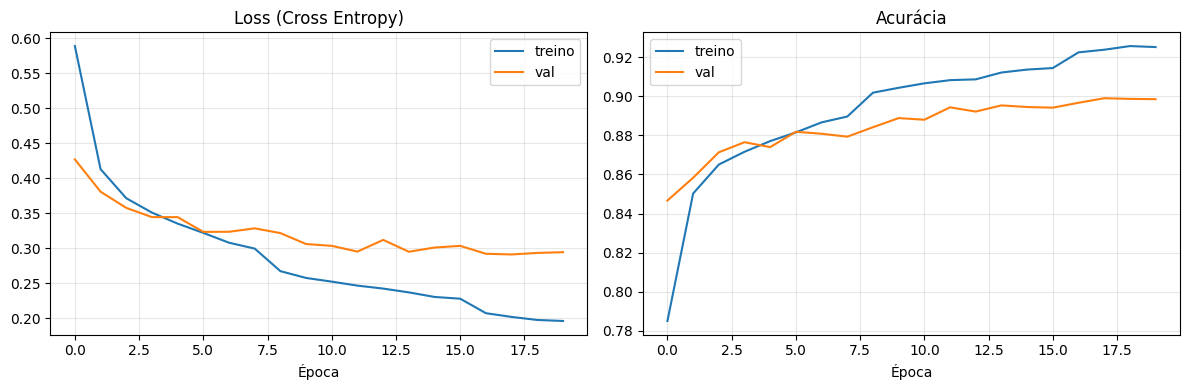

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historico["train_loss"], label="treino")
axes[0].plot(historico["val_loss"], label="val")
axes[0].set_title("Loss (Cross Entropy)")
axes[0].set_xlabel("Época")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(historico["train_acc"], label="treino")
axes[1].plot(historico["val_acc"], label="val")
axes[1].set_title("Acurácia")
axes[1].set_xlabel("Época")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Persistência: carregando o melhor modelo

Aqui demonstramos como **recarregar** o melhor checkpoint — essencial para deployment e reprodutibilidade.

In [25]:
modelo_final = MLP_FashionMNIST().to(device)
ckpt = torch.load("melhor_mlp_fashion.pth", map_location=device)
modelo_final.load_state_dict(ckpt["modelo_state"])
modelo_final.eval()
print(f"Carregado checkpoint da época {ckpt['epoca']} (val_acc={ckpt['val_acc']:.4f})")

Carregado checkpoint da época 18 (val_acc=0.8990)


## 11. Avaliação no conjunto de teste

In [26]:
all_y, all_pred = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits = modelo_final(Xb)
        preds = logits.argmax(1).cpu().numpy()
        all_y.extend(yb.numpy()); all_pred.extend(preds)

all_y, all_pred = np.array(all_y), np.array(all_pred)
acc = (all_y == all_pred).mean()
print(f"Acurácia no teste: {acc:.4f}\n")
print(classification_report(all_y, all_pred, target_names=CLASSES))

Acurácia no teste: 0.8936

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.86      0.85      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.82      0.81      0.82      1000
       Dress       0.89      0.90      0.90      1000
        Coat       0.81      0.84      0.82      1000
      Sandal       0.99      0.95      0.97      1000
       Shirt       0.74      0.69      0.71      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



## 12. Matriz de confusão

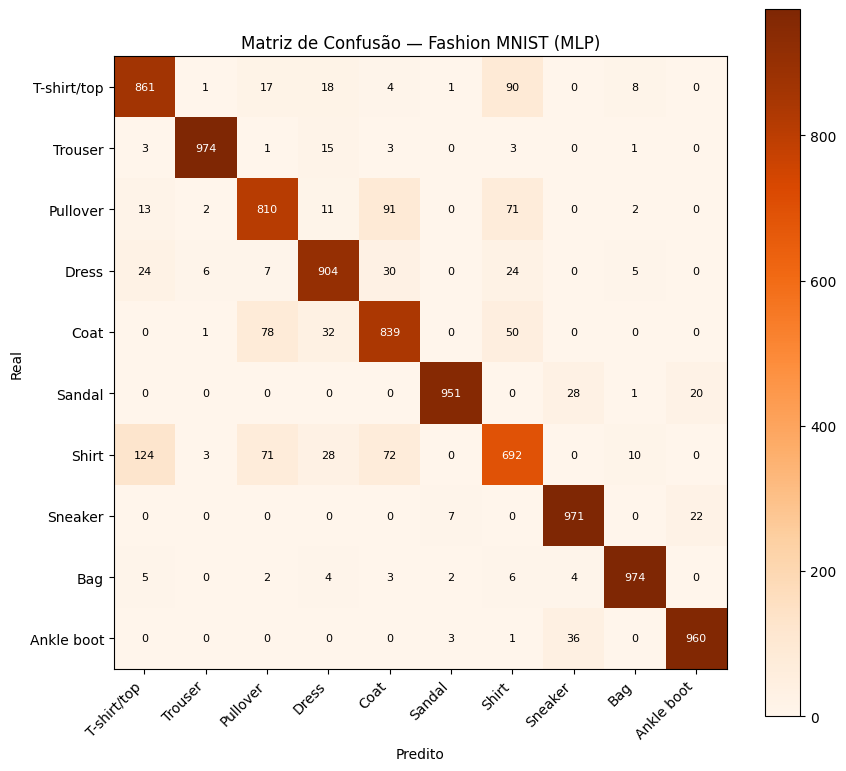

In [27]:
cm = confusion_matrix(all_y, all_pred)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Oranges")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predito"); ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão — Fashion MNIST (MLP)")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black',
                fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 13. Visualizando predições

c:\Users\307145\Downloads\AM - 16-04-26\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


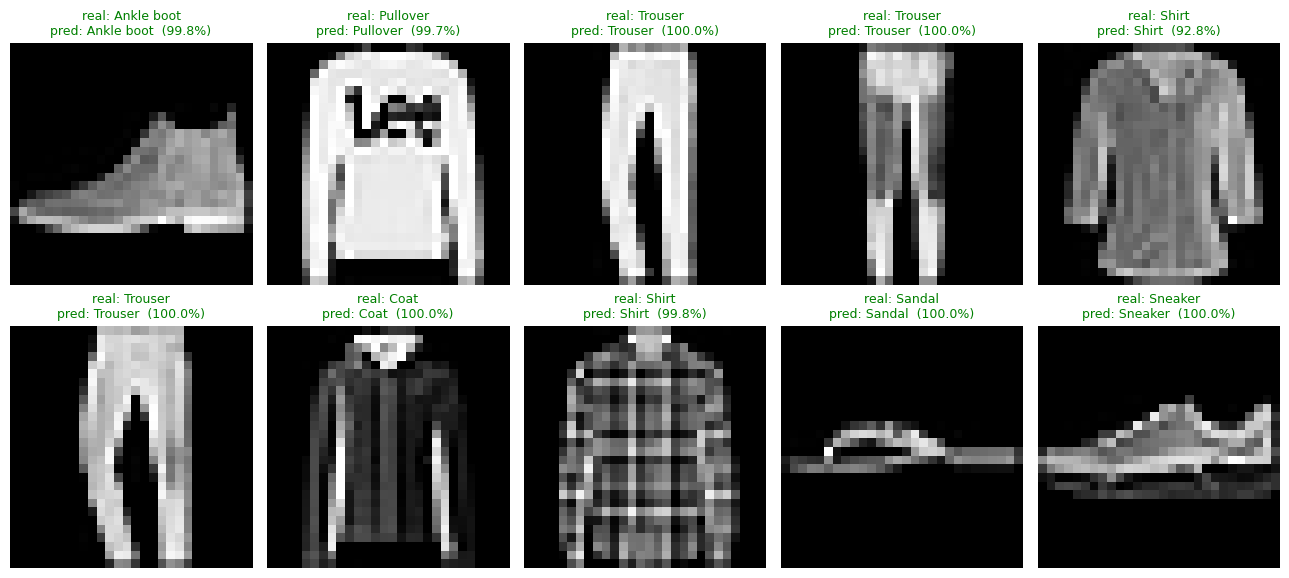

In [28]:
Xb, yb = next(iter(test_loader))
with torch.no_grad():
    logits = modelo_final(Xb.to(device))
    probs  = torch.softmax(logits, dim=1).cpu()
    preds  = probs.argmax(1)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for i, ax in enumerate(axes.flat):
    img = desnormalizar(Xb[i]).squeeze().numpy()
    ax.imshow(img, cmap='gray')
    cor = "green" if preds[i] == yb[i] else "red"
    ax.set_title(
        f"real: {CLASSES[yb[i]]}\npred: {CLASSES[preds[i]]}  ({probs[i, preds[i]]*100:.1f}%)",
        color=cor, fontsize=9
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

## 14. Abrindo o TensorBoard

No terminal, dentro da pasta deste notebook:

```bash
tensorboard --logdir=runs --port=6006
```

Abra então **http://localhost:6006** no navegador.

Você verá:
- **Scalars**: curvas de loss, acurácia e learning rate
- **Graphs**: arquitetura completa do MLP
- **Histograms**: distribuição dos pesos por época
- Comparação entre múltiplos experimentos (cada subpasta em `runs/`)

### Dentro do notebook:
```python
%load_ext tensorboard
%tensorboard --logdir runs
```

In [32]:
%load_ext tensorboard  
%tensorboard --logdir runs --port 8080

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


## Resumo

- Carregamos o **Fashion MNIST** via `torchvision.datasets`.
- Usamos o **DataLoader** com batches e shuffle.
- Construímos um **MLP** com camadas totalmente conectadas, ReLU e Dropout.
- **Persistimos** o melhor checkpoint com `torch.save`.
- **Carregamos** e avaliamos o modelo no teste.
- Acompanhamos loss, acurácia, LR, histogramas e grafo do modelo no **TensorBoard**.